In [6]:
import gc
import random
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.style.use('seaborn-v0_8')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

PROJECT_DIR = Path('.') if Path('datasets').exists() or Path('embeddings').exists() else Path('Текущий контроль 11-12')
DATASETS_DIR = PROJECT_DIR / 'datasets'
SURNAME_PATH = DATASETS_DIR / 'surnames' / 'surnames.csv'
EMBEDDINGS_PATH = PROJECT_DIR / 'embeddings' / 'globe_100_rows.txt'
MODELS_DIR = PROJECT_DIR / 'saved_models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def clear_memory(*objects):
    for obj in objects:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zа-я0-9' ]+", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


class Vocab:
    def __init__(self, tokens, min_freq=1, specials=None):
        specials = specials or ['<PAD>', '<UNK>']
        self.itos = []
        for token in specials:
            if token not in self.itos:
                self.itos.append(token)
        counts = Counter(tokens)
        for token, freq in sorted(counts.items()):
            if freq >= min_freq and token not in self.itos:
                self.itos.append(token)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}
        self.pad_idx = self.stoi.get('<PAD>', 0)
        self.unk_idx = self.stoi.get('<UNK>', 1 if len(self.itos) > 1 else 0)

    def encode(self, tokens):
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def __len__(self):
        return len(self.itos)


class SequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx], len(self.sequences[idx])


def pad_collate(batch, pad_idx):
    sequences, labels, lengths = zip(*batch)
    lengths = torch.tensor(lengths, dtype=torch.long)
    max_len = max(lengths).item()
    padded = torch.full((len(batch), max_len), pad_idx, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded, labels, lengths


def train_classifier(model, train_loader, test_loader, criterion, optimizer, epochs, device, patience=3, min_delta=0.0):
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    best_loss = float('inf')
    bad_epochs = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0

        for X_batch, y_batch, lengths in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lengths = lengths.to(device)

            optimizer.zero_grad()
            logits = model(X_batch, lengths)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)

        train_loss = running_loss / max(total, 1)
        test_loss, test_acc = evaluate_classifier(model, test_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f'epoch {epoch}/{epochs}: train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}')

        if test_loss < best_loss - min_delta:
            best_loss = test_loss
            bad_epochs = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f'early stopping at epoch {epoch}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


@torch.no_grad()
def evaluate_classifier(model, data_loader, criterion, device):
    model.eval()
    losses = []
    preds = []
    targets = []

    for X_batch, y_batch, lengths in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        lengths = lengths.to(device)

        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        losses.append(loss.item() * X_batch.size(0))
        preds.extend(logits.argmax(dim=1).cpu().tolist())
        targets.extend(y_batch.cpu().tolist())

    mean_loss = sum(losses) / max(len(targets), 1)
    acc = accuracy_score(targets, preds) if targets else 0.0
    return mean_loss, acc


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train_loss')
    axes[0].plot(history['test_loss'], label='test_loss')
    axes[0].set_title(title + ' loss')
    axes[0].legend()
    axes[1].plot(history['test_acc'], label='test_acc', color='green')
    axes[1].set_title(title + ' accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def tokenize_surname(name):
    return list(str(name).lower())


def prepare_surname_loaders(batch_size=256, min_freq=1):
    df = pd.read_csv(SURNAME_PATH)
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=df['nationality']
    )
    char_tokens = []
    for surname in train_df['surname']:
        char_tokens.extend(tokenize_surname(surname))
    vocab = Vocab(char_tokens, min_freq=min_freq)
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_df['nationality'])
    y_test = label_encoder.transform(test_df['nationality'])
    X_train = [vocab.encode(tokenize_surname(name)) for name in train_df['surname']]
    X_test = [vocab.encode(tokenize_surname(name)) for name in test_df['surname']]
    train_ds = SequenceDataset(X_train, y_train)
    test_ds = SequenceDataset(X_test, y_test)
    collate = lambda batch: pad_collate(batch, vocab.pad_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
    return df, vocab, label_encoder, train_loader, test_loader


def load_pretrained_vectors(path):
    vectors = {}
    dim = None
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            token = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            vectors[token] = vector
            dim = len(vector)
    return vectors, dim


def build_char_embedding_matrix(vocab, vector_path):
    vectors, dim = load_pretrained_vectors(vector_path)
    matrix = np.random.normal(0, 0.05, size=(len(vocab), dim)).astype(np.float32)
    matrix[vocab.pad_idx] = 0.0
    covered = 0

    for token, idx in vocab.stoi.items():
        if token in {'<PAD>', '<UNK>'}:
            continue
        if token in vectors:
            matrix[idx] = vectors[token]
            covered += 1
            continue
        matched = [vec for word, vec in vectors.items() if word and word[0] == token]
        if matched:
            matrix[idx] = np.mean(matched, axis=0)
            covered += 1

    print(f'char embedding coverage: {covered}/{len(vocab)}')
    return torch.tensor(matrix, dtype=torch.float32)


def read_review_file(path):
    path = Path(path)
    if path.suffix.lower() == '.txt':
        lines = [line.strip() for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
        return pd.Series(lines, name='text')
    df = pd.read_csv(path)
    if 'text' in df.columns:
        return df['text'].astype(str)
    obj_cols = [col for col in df.columns if df[col].dtype == 'object']
    if obj_cols:
        return df[obj_cols[0]].astype(str)
    return df.iloc[:, 0].astype(str)


def resolve_review_files():
    candidate_roots = [
        DATASETS_DIR / 'news',
        DATASETS_DIR / 'polarity',
        Path('Текущий контроль 15-16/Практические занятия 15-16/datasets/polarity'),
        Path('Текущий контроль 9-10/data'),
    ]
    for root in candidate_roots:
        if not root.exists():
            continue
        files = [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in {'.txt', '.csv'}]
        pos = next((p for p in files if 'positive' in p.name.lower()), None)
        neg = next((p for p in files if 'negative' in p.name.lower()), None)
        if pos and neg:
            return pos, neg
    raise FileNotFoundError('Не найдены файлы positive/negative reviews. Заполни datasets/news или оставь fallback на соседние контрольные.')


def tokenize_review(text):
    return preprocess_text(text).split()


def prepare_review_loaders(batch_size=128, min_freq=2, max_len=80):
    pos_path, neg_path = resolve_review_files()
    pos = read_review_file(pos_path)
    neg = read_review_file(neg_path)
    review_df = pd.DataFrame({
        'text': pd.concat([pos, neg], ignore_index=True),
        'label': [1] * len(pos) + [0] * len(neg)
    })
    train_df, test_df = train_test_split(
        review_df,
        test_size=0.2,
        random_state=SEED,
        stratify=review_df['label']
    )
    train_tokens = train_df['text'].map(tokenize_review)
    test_tokens = test_df['text'].map(tokenize_review)
    vocab_tokens = [token for seq in train_tokens for token in seq]
    vocab = Vocab(vocab_tokens, min_freq=min_freq)

    def encode(seq):
        encoded = vocab.encode(seq[:max_len])
        return encoded or [vocab.unk_idx]

    X_train = [encode(seq) for seq in train_tokens]
    X_test = [encode(seq) for seq in test_tokens]
    y_train = train_df['label'].to_numpy()
    y_test = test_df['label'].to_numpy()
    train_ds = SequenceDataset(X_train, y_train)
    test_ds = SequenceDataset(X_test, y_test)
    collate = lambda batch: pad_collate(batch, vocab.pad_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
    print('review files:', pos_path, neg_path)
    print('review_df shape:', review_df.shape)
    return review_df, vocab, train_loader, test_loader, train_df, test_df


class BuiltinRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_classes, pad_idx, rnn_type='rnn', embedding_weights=None, freeze_embedding=False):
        super().__init__()
        if embedding_weights is None:
            self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        else:
            self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=freeze_embedding, padding_idx=pad_idx)
            emb_dim = embedding_weights.size(1)
        if rnn_type == 'rnn':
            self.encoder = nn.RNN(emb_dim, hidden_size, batch_first=True)
        elif rnn_type == 'lstm':
            self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True)
        elif rnn_type == 'gru':
            self.encoder = nn.GRU(emb_dim, hidden_size, batch_first=True)
        else:
            raise ValueError(f'unknown rnn_type: {rnn_type}')
        self.dropout = nn.Dropout(0.25)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        outputs, _ = self.encoder(emb)
        idx = (lengths - 1).clamp(min=0)
        last_hidden = outputs[torch.arange(x.size(0), device=x.device), idx]
        return self.fc(self.dropout(last_hidden))


def show_surname_predictions(model, vocab, label_encoder, names):
    model.eval()
    sequences = [vocab.encode(tokenize_surname(name)) for name in names]
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = torch.full((len(sequences), lengths.max().item()), vocab.pad_idx, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    with torch.no_grad():
        logits = model(padded.to(device), lengths.to(device))
        probs = logits.softmax(dim=1).cpu().numpy()
    for name, prob in zip(names, probs):
        top_idx = np.argsort(prob)[::-1][:3]
        top = [(label_encoder.classes_[i], float(prob[i])) for i in top_idx]
        print(name, '->', top)


def show_review_predictions(model, vocab, texts):
    model.eval()
    sequences = [vocab.encode(tokenize_review(text)) or [vocab.unk_idx] for text in texts]
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = torch.full((len(sequences), lengths.max().item()), vocab.pad_idx, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    with torch.no_grad():
        logits = model(padded.to(device), lengths.to(device))
        probs = logits.softmax(dim=1).cpu().numpy()
    for text, prob in zip(texts, probs):
        pred = int(prob.argmax())
        preview = str(text).replace('\n', ' ')[:140]
        print(f'text={preview!r} -> pred={pred}, probs={[round(float(x), 4) for x in prob]}')


device: cuda:0


In [7]:
print('PROJECT_DIR =', PROJECT_DIR.resolve())
print('SURNAME_PATH exists =', SURNAME_PATH.exists(), SURNAME_PATH)
print('EMBEDDINGS_PATH exists =', EMBEDDINGS_PATH.exists(), EMBEDDINGS_PATH)
try:
    pos_path, neg_path = resolve_review_files()
    print('review files =', pos_path, neg_path)
except FileNotFoundError as e:
    print(e)


PROJECT_DIR = /home/aleksey/Documents/mirea_lab/6 sem/algo-ml/Текущий контроль 11-12
SURNAME_PATH exists = True datasets/surnames/surnames.csv
EMBEDDINGS_PATH exists = True embeddings/globe_100_rows.txt
review files = datasets/news/positive_reviews.txt datasets/news/negative_reviews.txt


## 1. Классификация фамилий (RNN)

Датасет: https://disk.yandex.ru/d/frNchuaBQVLxyA?w=1


1.1 Используя класс `nn.RNNCell` (абстракцию для отдельного временного шага RNN), реализуйте простейшую рекуррентную сеть Элмана в виде класса `RNN`. Используя созданный класс `RNN`, решите задачу классификации фамилий. 



surname_df shape: (10980, 2)
surname vocab size: 57
classes: ['Arabic', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Greek', 'Irish', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Scottish', 'Spanish', 'Vietnamese']
epoch 1/18: train_loss=2.3515 test_loss=2.1419 test_acc=0.2978
epoch 2/18: train_loss=2.0475 test_loss=1.9748 test_acc=0.4039
epoch 3/18: train_loss=1.9037 test_loss=1.8585 test_acc=0.4472
epoch 4/18: train_loss=1.7434 test_loss=1.6788 test_acc=0.5228
epoch 5/18: train_loss=1.5755 test_loss=1.5592 test_acc=0.5592
epoch 6/18: train_loss=1.4602 test_loss=1.4631 test_acc=0.5911
epoch 7/18: train_loss=1.3761 test_loss=1.4047 test_acc=0.6093
epoch 8/18: train_loss=1.3134 test_loss=1.3387 test_acc=0.6298
epoch 9/18: train_loss=1.2594 test_loss=1.3114 test_acc=0.6425
epoch 10/18: train_loss=1.2176 test_loss=1.2659 test_acc=0.6457
epoch 11/18: train_loss=1.1742 test_loss=1.2309 test_acc=0.6580
epoch 12/18: train_loss=1.1405 test_loss=1.2088 te

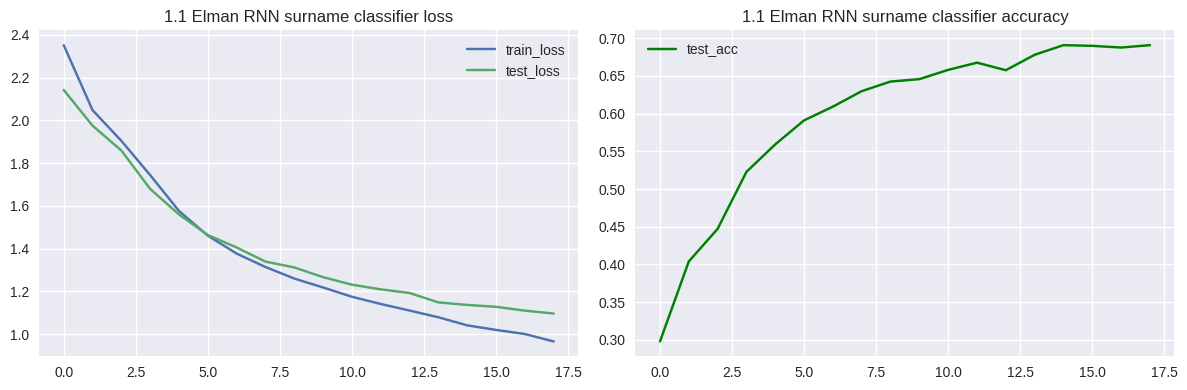

1.1 accuracy: 0.6908014571948998
Ivanov -> [('Russian', 0.9920752048492432), ('Czech', 0.0021516273263841867), ('English', 0.00181415060069412)]
Petrov -> [('Russian', 0.9642173647880554), ('Czech', 0.012145532295107841), ('English', 0.007495655212551355)]
Smith -> [('English', 0.7075704336166382), ('German', 0.10460739582777023), ('Russian', 0.055400680750608444)]
Kim -> [('Chinese', 0.400171160697937), ('Korean', 0.2158840000629425), ('Russian', 0.19332894682884216)]
Garcia -> [('Arabic', 0.6833904981613159), ('Spanish', 0.11199616640806198), ('Italian', 0.07471507042646408)]


In [8]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = nn.RNNCell(input_size, hidden_size)

    def forward(self, x, h=None):
        batch_size, seq_len, _ = x.shape
        if h is None:
            h = x.new_zeros(batch_size, self.hidden_size)
        outputs = []
        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
            outputs.append(h.unsqueeze(1))
        outputs = torch.cat(outputs, dim=1)
        return outputs, h


class SurnameElmanClassifier(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_classes, pad_idx):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_idx = pad_idx
        self.rnn = RNN(vocab_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        one_hot = F.one_hot(x, num_classes=self.vocab_size).float()
        one_hot[:, :, self.pad_idx] = 0.0
        outputs, _ = self.rnn(one_hot)
        idx = (lengths - 1).clamp(min=0)
        last_hidden = outputs[torch.arange(x.size(0), device=x.device), idx]
        return self.fc(last_hidden)


surname_df, surname_vocab, surname_le, train_loader, test_loader = prepare_surname_loaders(batch_size=256)
print('surname_df shape:', surname_df.shape)
print('surname vocab size:', len(surname_vocab))
print('classes:', list(surname_le.classes_))

model_elman = SurnameElmanClassifier(len(surname_vocab), hidden_size=128, num_classes=len(surname_le.classes_), pad_idx=surname_vocab.pad_idx).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_elman.parameters(), lr=1e-3)
history_elman = train_classifier(model_elman, train_loader, test_loader, criterion, optimizer, epochs=18, device=device, patience=4, min_delta=1e-3)
plot_history(history_elman, '1.1 Elman RNN surname classifier')
loss_elman, acc_elman = evaluate_classifier(model_elman, test_loader, criterion, device)
print('1.1 accuracy:', acc_elman)
show_surname_predictions(model_elman, surname_vocab, surname_le, ['Ivanov', 'Petrov', 'Smith', 'Kim', 'Garcia'])


1.2 Замените модуль `RNN` из 1.1 на модули `nn.RNN`, `nn.LSTM` и `nn.GRU` (не забудьте указать аргумент `batch_first=True`). Сравните результаты работы.



Training surname RNN model
epoch 1/18: train_loss=2.1240 test_loss=1.7219 test_acc=0.5150
epoch 2/18: train_loss=1.5880 test_loss=1.4660 test_acc=0.5893
epoch 3/18: train_loss=1.4001 test_loss=1.3385 test_acc=0.6152
epoch 4/18: train_loss=1.2832 test_loss=1.2479 test_acc=0.6425
epoch 5/18: train_loss=1.1967 test_loss=1.1934 test_acc=0.6630
epoch 6/18: train_loss=1.1365 test_loss=1.1397 test_acc=0.6781
epoch 7/18: train_loss=1.0741 test_loss=1.1055 test_acc=0.6831
epoch 8/18: train_loss=1.0292 test_loss=1.0926 test_acc=0.6917
epoch 9/18: train_loss=1.0001 test_loss=1.0401 test_acc=0.7008
epoch 10/18: train_loss=0.9607 test_loss=1.0210 test_acc=0.7036
epoch 11/18: train_loss=0.9202 test_loss=0.9844 test_acc=0.7209
epoch 12/18: train_loss=0.8890 test_loss=0.9659 test_acc=0.7199
epoch 13/18: train_loss=0.8652 test_loss=0.9453 test_acc=0.7277
epoch 14/18: train_loss=0.8362 test_loss=0.9447 test_acc=0.7259
epoch 15/18: train_loss=0.8186 test_loss=0.9361 test_acc=0.7190
epoch 16/18: train_lo

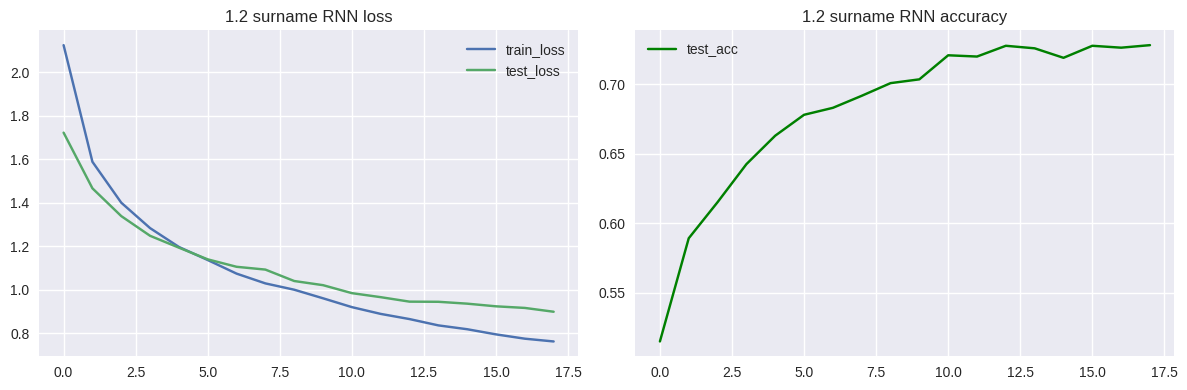

RNN accuracy: 0.7281

Training surname LSTM model
epoch 1/18: train_loss=2.3999 test_loss=1.9244 test_acc=0.4754
epoch 2/18: train_loss=1.7622 test_loss=1.5985 test_acc=0.5474
epoch 3/18: train_loss=1.4992 test_loss=1.4133 test_acc=0.5902
epoch 4/18: train_loss=1.3338 test_loss=1.2901 test_acc=0.6270
epoch 5/18: train_loss=1.2249 test_loss=1.1952 test_acc=0.6566
epoch 6/18: train_loss=1.1307 test_loss=1.1305 test_acc=0.6721
epoch 7/18: train_loss=1.0614 test_loss=1.0768 test_acc=0.6908
epoch 8/18: train_loss=0.9959 test_loss=1.0414 test_acc=0.6972
epoch 9/18: train_loss=0.9513 test_loss=1.0039 test_acc=0.7140
epoch 10/18: train_loss=0.8976 test_loss=0.9716 test_acc=0.7140
epoch 11/18: train_loss=0.8570 test_loss=0.9440 test_acc=0.7318
epoch 12/18: train_loss=0.8212 test_loss=0.9217 test_acc=0.7363
epoch 13/18: train_loss=0.7931 test_loss=0.8939 test_acc=0.7354
epoch 14/18: train_loss=0.7581 test_loss=0.8746 test_acc=0.7413
epoch 15/18: train_loss=0.7281 test_loss=0.8571 test_acc=0.7500

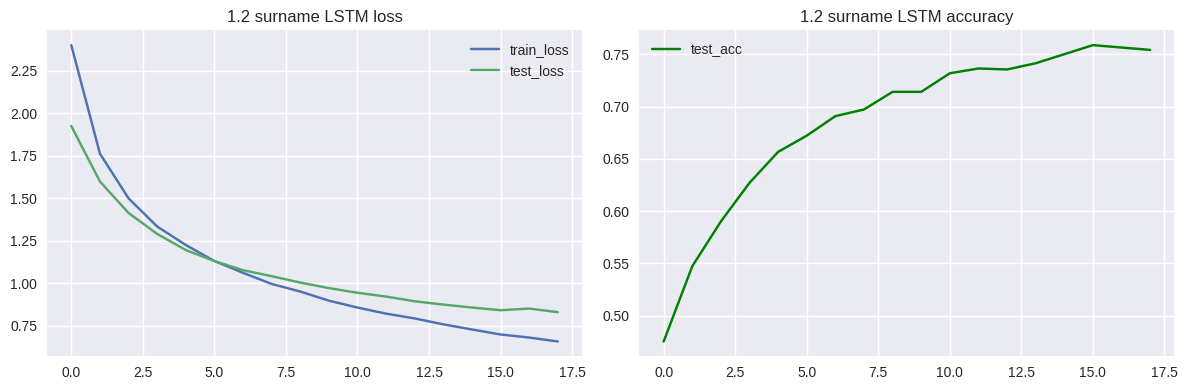

LSTM accuracy: 0.7541

Training surname GRU model
epoch 1/18: train_loss=2.3152 test_loss=1.8760 test_acc=0.4654
epoch 2/18: train_loss=1.7057 test_loss=1.5301 test_acc=0.5528
epoch 3/18: train_loss=1.4300 test_loss=1.3427 test_acc=0.6207
epoch 4/18: train_loss=1.2757 test_loss=1.2280 test_acc=0.6512
epoch 5/18: train_loss=1.1735 test_loss=1.1574 test_acc=0.6639
epoch 6/18: train_loss=1.0938 test_loss=1.0970 test_acc=0.6840
epoch 7/18: train_loss=1.0276 test_loss=1.0596 test_acc=0.6885
epoch 8/18: train_loss=0.9709 test_loss=1.0179 test_acc=0.7090
epoch 9/18: train_loss=0.9241 test_loss=0.9837 test_acc=0.7190
epoch 10/18: train_loss=0.8829 test_loss=0.9643 test_acc=0.7231
epoch 11/18: train_loss=0.8451 test_loss=0.9381 test_acc=0.7286
epoch 12/18: train_loss=0.8139 test_loss=0.9139 test_acc=0.7345
epoch 13/18: train_loss=0.7826 test_loss=0.9000 test_acc=0.7409
epoch 14/18: train_loss=0.7524 test_loss=0.8802 test_acc=0.7386
epoch 15/18: train_loss=0.7273 test_loss=0.8641 test_acc=0.7436

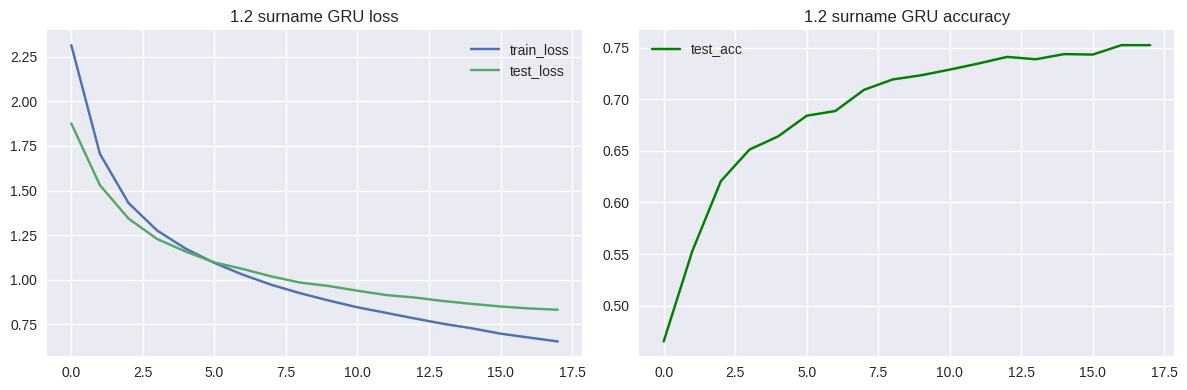

GRU accuracy: 0.7523
1.2 summary:
RNN {'loss': 0.8989061666533812, 'acc': 0.7281420765027322}
LSTM {'loss': 0.8299134571261311, 'acc': 0.7540983606557377}
GRU {'loss': 0.8316779347282507, 'acc': 0.7522768670309654}
best 1.2 model: LSTM
Ivanov -> [('Russian', 0.9964537620544434), ('Czech', 0.0013649306492879987), ('Spanish', 0.00036261777859181166)]
Petrov -> [('Russian', 0.9810780882835388), ('English', 0.008508999831974506), ('Czech', 0.004709473345428705)]
Smith -> [('English', 0.5176137685775757), ('German', 0.24207261204719543), ('Russian', 0.04581628739833832)]
Kim -> [('Arabic', 0.2511295974254608), ('Korean', 0.21536901593208313), ('Chinese', 0.2132013589143753)]
Garcia -> [('Italian', 0.36037400364875793), ('Spanish', 0.256112277507782), ('Czech', 0.16580748558044434)]


In [9]:
surname_df, surname_vocab, surname_le, train_loader, test_loader = prepare_surname_loaders(batch_size=256)
criterion = nn.CrossEntropyLoss()
results_12 = {}
best_model_12 = None
best_name_12 = None
best_acc_12 = -1.0

for rnn_type in ['rnn', 'lstm', 'gru']:
    model = BuiltinRNNClassifier(
        vocab_size=len(surname_vocab),
        emb_dim=32,
        hidden_size=128,
        num_classes=len(surname_le.classes_),
        pad_idx=surname_vocab.pad_idx,
        rnn_type=rnn_type,
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    print(f'\nTraining surname {rnn_type.upper()} model')
    history = train_classifier(model, train_loader, test_loader, criterion, optimizer, epochs=18, device=device, patience=4, min_delta=1e-3)
    plot_history(history, f'1.2 surname {rnn_type.upper()}')
    loss, acc = evaluate_classifier(model, test_loader, criterion, device)
    results_12[rnn_type] = {'loss': loss, 'acc': acc}
    print(f'{rnn_type.upper()} accuracy: {acc:.4f}')
    if acc > best_acc_12:
        if best_model_12 is not None:
            best_model_12.cpu()
            clear_memory(best_model_12)
        best_model_12 = model
        best_name_12 = rnn_type
        best_acc_12 = acc
    else:
        model.cpu()
        clear_memory(model, optimizer)

print('1.2 summary:')
for name, metrics in results_12.items():
    print(name.upper(), metrics)

print('best 1.2 model:', best_name_12.upper())
show_surname_predictions(best_model_12, surname_vocab, surname_le, ['Ivanov', 'Petrov', 'Smith', 'Kim', 'Garcia'])


1.3 Загрузите предобученные эмбеддинги (https://disk.yandex.ru/d/BHuT2tEXr_yBOQ?w=1) в модуль `nn.Embedding` и обучите модели из 1.2.


char embedding coverage: 21/57

Training pretrained surname RNN model
epoch 1/18: train_loss=2.2697 test_loss=2.0281 test_acc=0.4057
epoch 2/18: train_loss=1.8915 test_loss=1.7323 test_acc=0.4868
epoch 3/18: train_loss=1.6346 test_loss=1.5727 test_acc=0.5373
epoch 4/18: train_loss=1.4832 test_loss=1.4514 test_acc=0.5692
epoch 5/18: train_loss=1.3691 test_loss=1.3678 test_acc=0.6056
epoch 6/18: train_loss=1.2992 test_loss=1.2961 test_acc=0.6225
epoch 7/18: train_loss=1.2415 test_loss=1.2451 test_acc=0.6352
epoch 8/18: train_loss=1.1899 test_loss=1.2063 test_acc=0.6507
epoch 9/18: train_loss=1.1480 test_loss=1.1786 test_acc=0.6617
epoch 10/18: train_loss=1.1188 test_loss=1.1492 test_acc=0.6653
epoch 11/18: train_loss=1.0855 test_loss=1.1283 test_acc=0.6767
epoch 12/18: train_loss=1.0508 test_loss=1.0939 test_acc=0.6876
epoch 13/18: train_loss=1.0182 test_loss=1.0699 test_acc=0.7008
epoch 14/18: train_loss=0.9956 test_loss=1.0491 test_acc=0.7013
epoch 15/18: train_loss=0.9700 test_loss=1.

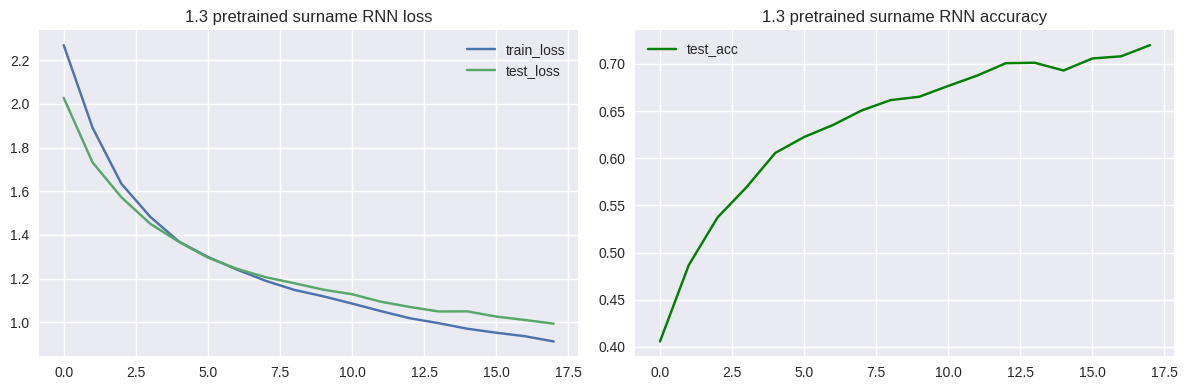

pretrained RNN accuracy: 0.7199

Training pretrained surname LSTM model
epoch 1/18: train_loss=2.3695 test_loss=2.1160 test_acc=0.3502
epoch 2/18: train_loss=2.0086 test_loss=1.8803 test_acc=0.4344
epoch 3/18: train_loss=1.8137 test_loss=1.7157 test_acc=0.4913
epoch 4/18: train_loss=1.6357 test_loss=1.5523 test_acc=0.5483
epoch 5/18: train_loss=1.4996 test_loss=1.4423 test_acc=0.5820
epoch 6/18: train_loss=1.4014 test_loss=1.3748 test_acc=0.5924
epoch 7/18: train_loss=1.3239 test_loss=1.3199 test_acc=0.6084
epoch 8/18: train_loss=1.2660 test_loss=1.2609 test_acc=0.6343
epoch 9/18: train_loss=1.2159 test_loss=1.2201 test_acc=0.6498
epoch 10/18: train_loss=1.1640 test_loss=1.1832 test_acc=0.6603
epoch 11/18: train_loss=1.1204 test_loss=1.1490 test_acc=0.6712
epoch 12/18: train_loss=1.0679 test_loss=1.1181 test_acc=0.6785
epoch 13/18: train_loss=1.0435 test_loss=1.0944 test_acc=0.6844
epoch 14/18: train_loss=1.0059 test_loss=1.0552 test_acc=0.6963
epoch 15/18: train_loss=0.9694 test_loss=

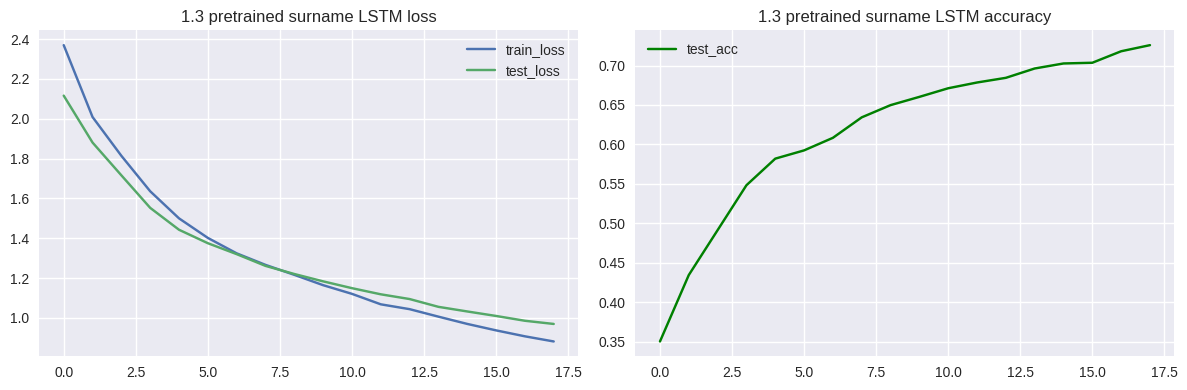

pretrained LSTM accuracy: 0.7259

Training pretrained surname GRU model
epoch 1/18: train_loss=2.3529 test_loss=2.0858 test_acc=0.3921
epoch 2/18: train_loss=1.9827 test_loss=1.8223 test_acc=0.4804
epoch 3/18: train_loss=1.7284 test_loss=1.6039 test_acc=0.5442
epoch 4/18: train_loss=1.5296 test_loss=1.4613 test_acc=0.5756
epoch 5/18: train_loss=1.3990 test_loss=1.3670 test_acc=0.5988
epoch 6/18: train_loss=1.3130 test_loss=1.2931 test_acc=0.6248
epoch 7/18: train_loss=1.2467 test_loss=1.2457 test_acc=0.6444
epoch 8/18: train_loss=1.1895 test_loss=1.1928 test_acc=0.6639
epoch 9/18: train_loss=1.1414 test_loss=1.1584 test_acc=0.6740
epoch 10/18: train_loss=1.0995 test_loss=1.1243 test_acc=0.6758
epoch 11/18: train_loss=1.0547 test_loss=1.0890 test_acc=0.6817
epoch 12/18: train_loss=1.0192 test_loss=1.0641 test_acc=0.6935
epoch 13/18: train_loss=0.9815 test_loss=1.0313 test_acc=0.6967
epoch 14/18: train_loss=0.9422 test_loss=1.0184 test_acc=0.7090
epoch 15/18: train_loss=0.9151 test_loss=

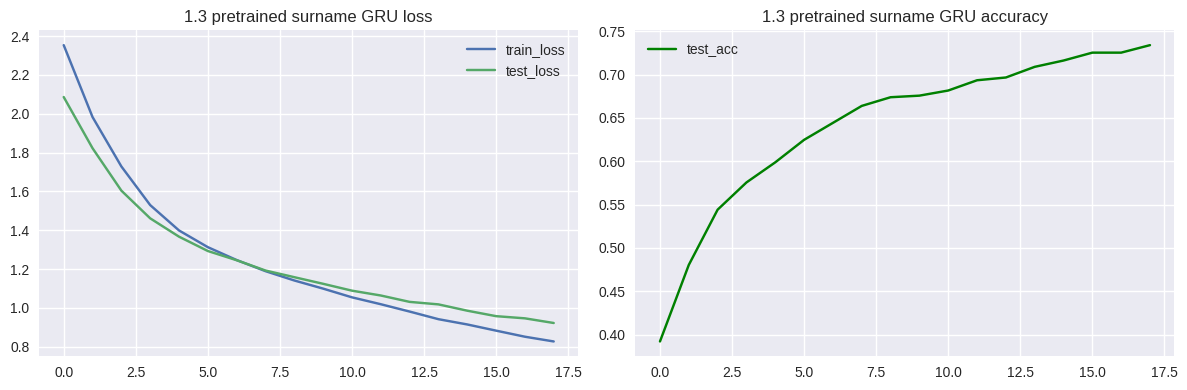

pretrained GRU accuracy: 0.7341
1.3 summary:
RNN {'loss': 0.9931512775751193, 'acc': 0.7199453551912568}
LSTM {'loss': 0.969263969440495, 'acc': 0.7258652094717668}
GRU {'loss': 0.9225468437962627, 'acc': 0.7340619307832422}
best 1.3 model: GRU
Ivanov -> [('Russian', 0.9882408976554871), ('Czech', 0.008545361459255219), ('Polish', 0.0009141010814346373)]
Petrov -> [('Russian', 0.9340872764587402), ('Czech', 0.02513403631746769), ('English', 0.02089141309261322)]
Smith -> [('English', 0.359067440032959), ('German', 0.2859365940093994), ('Russian', 0.1607857048511505)]
Kim -> [('Chinese', 0.45611777901649475), ('Korean', 0.24155373871326447), ('English', 0.06933026760816574)]
Garcia -> [('Arabic', 0.5399213433265686), ('Italian', 0.34324610233306885), ('Spanish', 0.062339287251234055)]


In [10]:
surname_df, surname_vocab, surname_le, train_loader, test_loader = prepare_surname_loaders(batch_size=256)
pretrained_matrix = build_char_embedding_matrix(surname_vocab, EMBEDDINGS_PATH)
criterion = nn.CrossEntropyLoss()
results_13 = {}
best_model_13 = None
best_name_13 = None
best_acc_13 = -1.0

for rnn_type in ['rnn', 'lstm', 'gru']:
    model = BuiltinRNNClassifier(
        vocab_size=len(surname_vocab),
        emb_dim=pretrained_matrix.size(1),
        hidden_size=128,
        num_classes=len(surname_le.classes_),
        pad_idx=surname_vocab.pad_idx,
        rnn_type=rnn_type,
        embedding_weights=pretrained_matrix,
        freeze_embedding=False,
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    print(f'\nTraining pretrained surname {rnn_type.upper()} model')
    history = train_classifier(model, train_loader, test_loader, criterion, optimizer, epochs=18, device=device, patience=4, min_delta=1e-3)
    plot_history(history, f'1.3 pretrained surname {rnn_type.upper()}')
    loss, acc = evaluate_classifier(model, test_loader, criterion, device)
    results_13[rnn_type] = {'loss': loss, 'acc': acc}
    print(f'pretrained {rnn_type.upper()} accuracy: {acc:.4f}')
    if acc > best_acc_13:
        if best_model_13 is not None:
            best_model_13.cpu()
            clear_memory(best_model_13)
        best_model_13 = model
        best_name_13 = rnn_type
        best_acc_13 = acc
    else:
        model.cpu()
        clear_memory(model, optimizer)

print('1.3 summary:')
for name, metrics in results_13.items():
    print(name.upper(), metrics)

print('best 1.3 model:', best_name_13.upper())
show_surname_predictions(best_model_13, surname_vocab, surname_le, ['Ivanov', 'Petrov', 'Smith', 'Kim', 'Garcia'])

if best_model_12 is not None:
    best_model_12.cpu()
clear_memory(pretrained_matrix)


## 2. Классификация обзоров на фильмы (RNN)

Датасет: https://disk.yandex.ru/d/tdinpb0nN_Dsrg

2.1 Создайте набор данных на основе файлов polarity/positive_reviews.csv (положительные отзывы) и polarity/negative_reviews.csv (отрицательные отзывы). Разбейте на обучающую и тестовую выборку.
  * токен = __слово__
  * данные для обучения в датасете представляются в виде последовательности индексов токенов
  * словарь создается на основе _только_ обучающей выборки. Для корректной обработки ситуаций, когда в тестовой выборке встретится токен, который не хранится в словаре, добавьте в словарь специальный токен `<UNK>`
  * добавьте предобработку текста

2.2. Обучите классификатор.
  
  * Для преобразования последовательности индексов в последовательность векторов используйте `nn.Embedding` 
    - подберите адекватную размерность вектора эмбеддинга: 
    - модуль `nn.Embedding` обучается

  * Используйте рекуррентные слои (`nn.RNN`, `nn.LSTM`, `nn.GRU`)


2.3 Измерить точность на тестовой выборке. Проверить работоспособность модели: придумать небольшой отзыв, прогнать его через модель и вывести номер предсказанного класса (сделать это для явно позитивного и явно негативного отзыва)
* Целевое значение accuracy на валидации - 70+%


review files: datasets/news/positive_reviews.txt datasets/news/negative_reviews.txt
review_df shape: (10662, 2)
review vocab size: 8972

Training review RNN model
epoch 1/12: train_loss=0.7000 test_loss=0.6922 test_acc=0.5584
epoch 2/12: train_loss=0.6560 test_loss=0.6786 test_acc=0.5813
epoch 3/12: train_loss=0.6234 test_loss=0.6714 test_acc=0.6057
epoch 4/12: train_loss=0.5905 test_loss=0.6638 test_acc=0.6282
epoch 5/12: train_loss=0.5525 test_loss=0.6685 test_acc=0.6226
epoch 6/12: train_loss=0.5081 test_loss=0.6718 test_acc=0.6507
epoch 7/12: train_loss=0.4641 test_loss=0.6761 test_acc=0.6606
early stopping at epoch 7


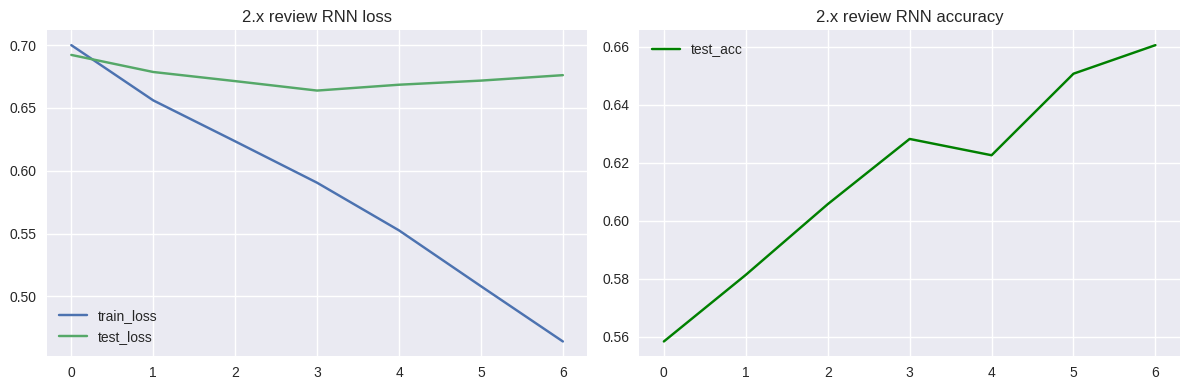

review RNN accuracy: 0.6282

Training review LSTM model
epoch 1/12: train_loss=0.6841 test_loss=0.6664 test_acc=0.5949
epoch 2/12: train_loss=0.6295 test_loss=0.6358 test_acc=0.6362
epoch 3/12: train_loss=0.5605 test_loss=0.6247 test_acc=0.6545
epoch 4/12: train_loss=0.4930 test_loss=0.5978 test_acc=0.6779
epoch 5/12: train_loss=0.4074 test_loss=0.6126 test_acc=0.6906
epoch 6/12: train_loss=0.3381 test_loss=0.6061 test_acc=0.7159
epoch 7/12: train_loss=0.2588 test_loss=0.6612 test_acc=0.7173
early stopping at epoch 7


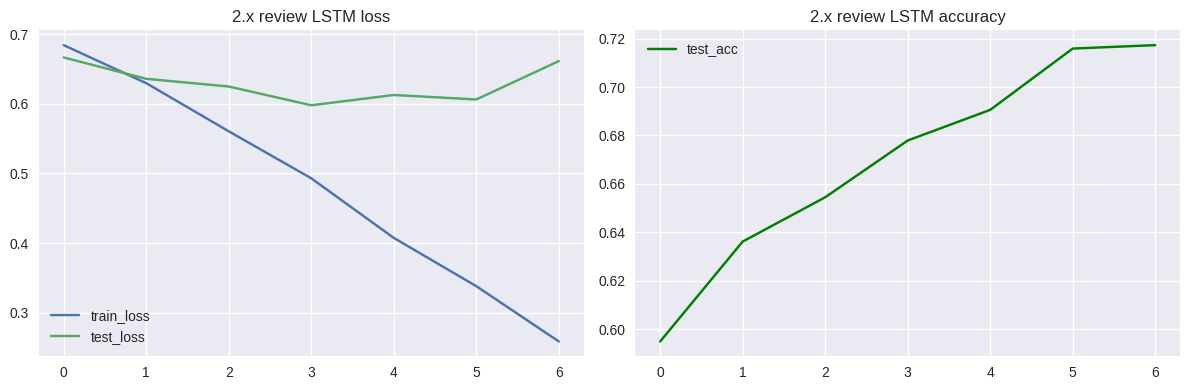

review LSTM accuracy: 0.6779

Training review GRU model
epoch 1/12: train_loss=0.6872 test_loss=0.6736 test_acc=0.5827
epoch 2/12: train_loss=0.6308 test_loss=0.6278 test_acc=0.6404
epoch 3/12: train_loss=0.5717 test_loss=0.6030 test_acc=0.6756
epoch 4/12: train_loss=0.5075 test_loss=0.5839 test_acc=0.7014
epoch 5/12: train_loss=0.4449 test_loss=0.5828 test_acc=0.7060
epoch 6/12: train_loss=0.3712 test_loss=0.6196 test_acc=0.7159
epoch 7/12: train_loss=0.3018 test_loss=0.7081 test_acc=0.7164
epoch 8/12: train_loss=0.2369 test_loss=0.7149 test_acc=0.7286
early stopping at epoch 8


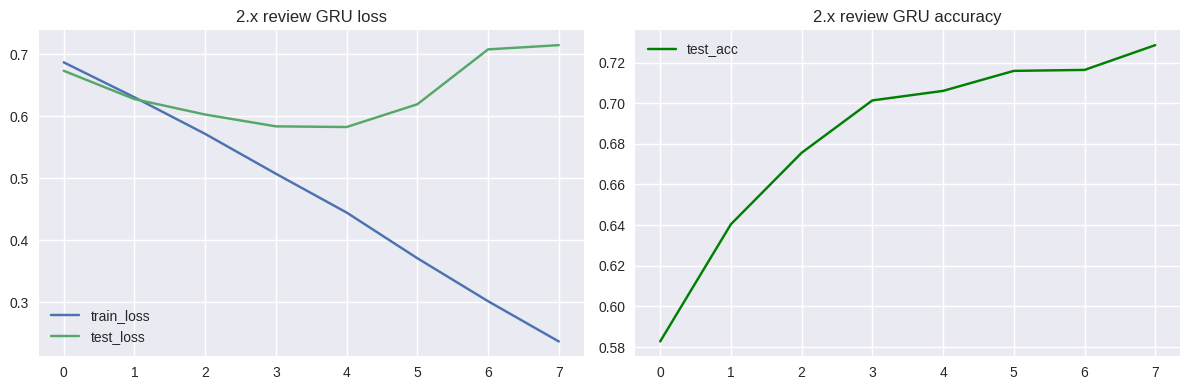

review GRU accuracy: 0.7060
2.x summary:
RNN {'loss': 0.6638499631939837, 'acc': 0.6282231598687295}
LSTM {'loss': 0.597807186760927, 'acc': 0.6779184247538678}
GRU {'loss': 0.5828279794743516, 'acc': 0.7060478199718706}
Best review model: GRU
Review classifier accuracy: 0.7060478199718706
text='this film is touching, smart and beautifully acted' -> pred=0, probs=[0.9542, 0.0458]
text='the movie is boring, messy and painfully slow' -> pred=1, probs=[0.3158, 0.6842]
text='this franchise has not spawned a single good film . the crap continues .' -> pred=0, probs=[0.6506, 0.3494]
true_label = 1
---
text='its gentle , touching story creeps into your heart .' -> pred=0, probs=[0.9809, 0.0191]
true_label = 0
---
text='one of the best rock documentaries ever . wilco is a phenomenal band with such an engrossing story that will capture the minds and hearts of' -> pred=0, probs=[0.9934, 0.0066]
true_label = 0
---
text='a film that presents an interesting , even sexy premise then ruins itself wit

In [11]:
review_df, review_vocab, review_train_loader, review_test_loader, review_train_df, review_test_df = prepare_review_loaders(batch_size=128, min_freq=2, max_len=80)
print('review vocab size:', len(review_vocab))
criterion = nn.CrossEntropyLoss()
review_results = {}
best_review_state = None
best_name_2 = None
best_acc_2 = -1.0

for rnn_type in ['rnn', 'lstm', 'gru']:
    model = BuiltinRNNClassifier(
        vocab_size=len(review_vocab),
        emb_dim=128,
        hidden_size=128,
        num_classes=2,
        pad_idx=review_vocab.pad_idx,
        rnn_type=rnn_type,
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    print(f'\nTraining review {rnn_type.upper()} model')
    history = train_classifier(model, review_train_loader, review_test_loader, criterion, optimizer, epochs=12, device=device, patience=3, min_delta=1e-3)
    plot_history(history, f'2.x review {rnn_type.upper()}')
    loss, acc = evaluate_classifier(model, review_test_loader, criterion, device)
    review_results[rnn_type] = {'loss': loss, 'acc': acc}
    print(f'review {rnn_type.upper()} accuracy: {acc:.4f}')
    if acc > best_acc_2:
        best_name_2 = rnn_type
        best_acc_2 = acc
        best_review_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.cpu()
    clear_memory(model, optimizer)

print('2.x summary:')
for name, metrics in review_results.items():
    print(name.upper(), metrics)

best_model = BuiltinRNNClassifier(
    vocab_size=len(review_vocab),
    emb_dim=128,
    hidden_size=128,
    num_classes=2,
    pad_idx=review_vocab.pad_idx,
    rnn_type=best_name_2,
).to(device)
best_model.load_state_dict(best_review_state)
review_loss, review_acc = evaluate_classifier(best_model, review_test_loader, criterion, device)
print('Best review model:', best_name_2.upper())
print('Review classifier accuracy:', review_acc)

sample_positive = 'this film is touching, smart and beautifully acted'
sample_negative = 'the movie is boring, messy and painfully slow'
show_review_predictions(best_model, review_vocab, [sample_positive, sample_negative])

real_examples = review_test_df.sample(5, random_state=SEED)
for _, row in real_examples.iterrows():
    text = row['text']
    true_label = int(row['label'])
    show_review_predictions(best_model, review_vocab, [text])
    print('true_label =', true_label)
    print('---')
